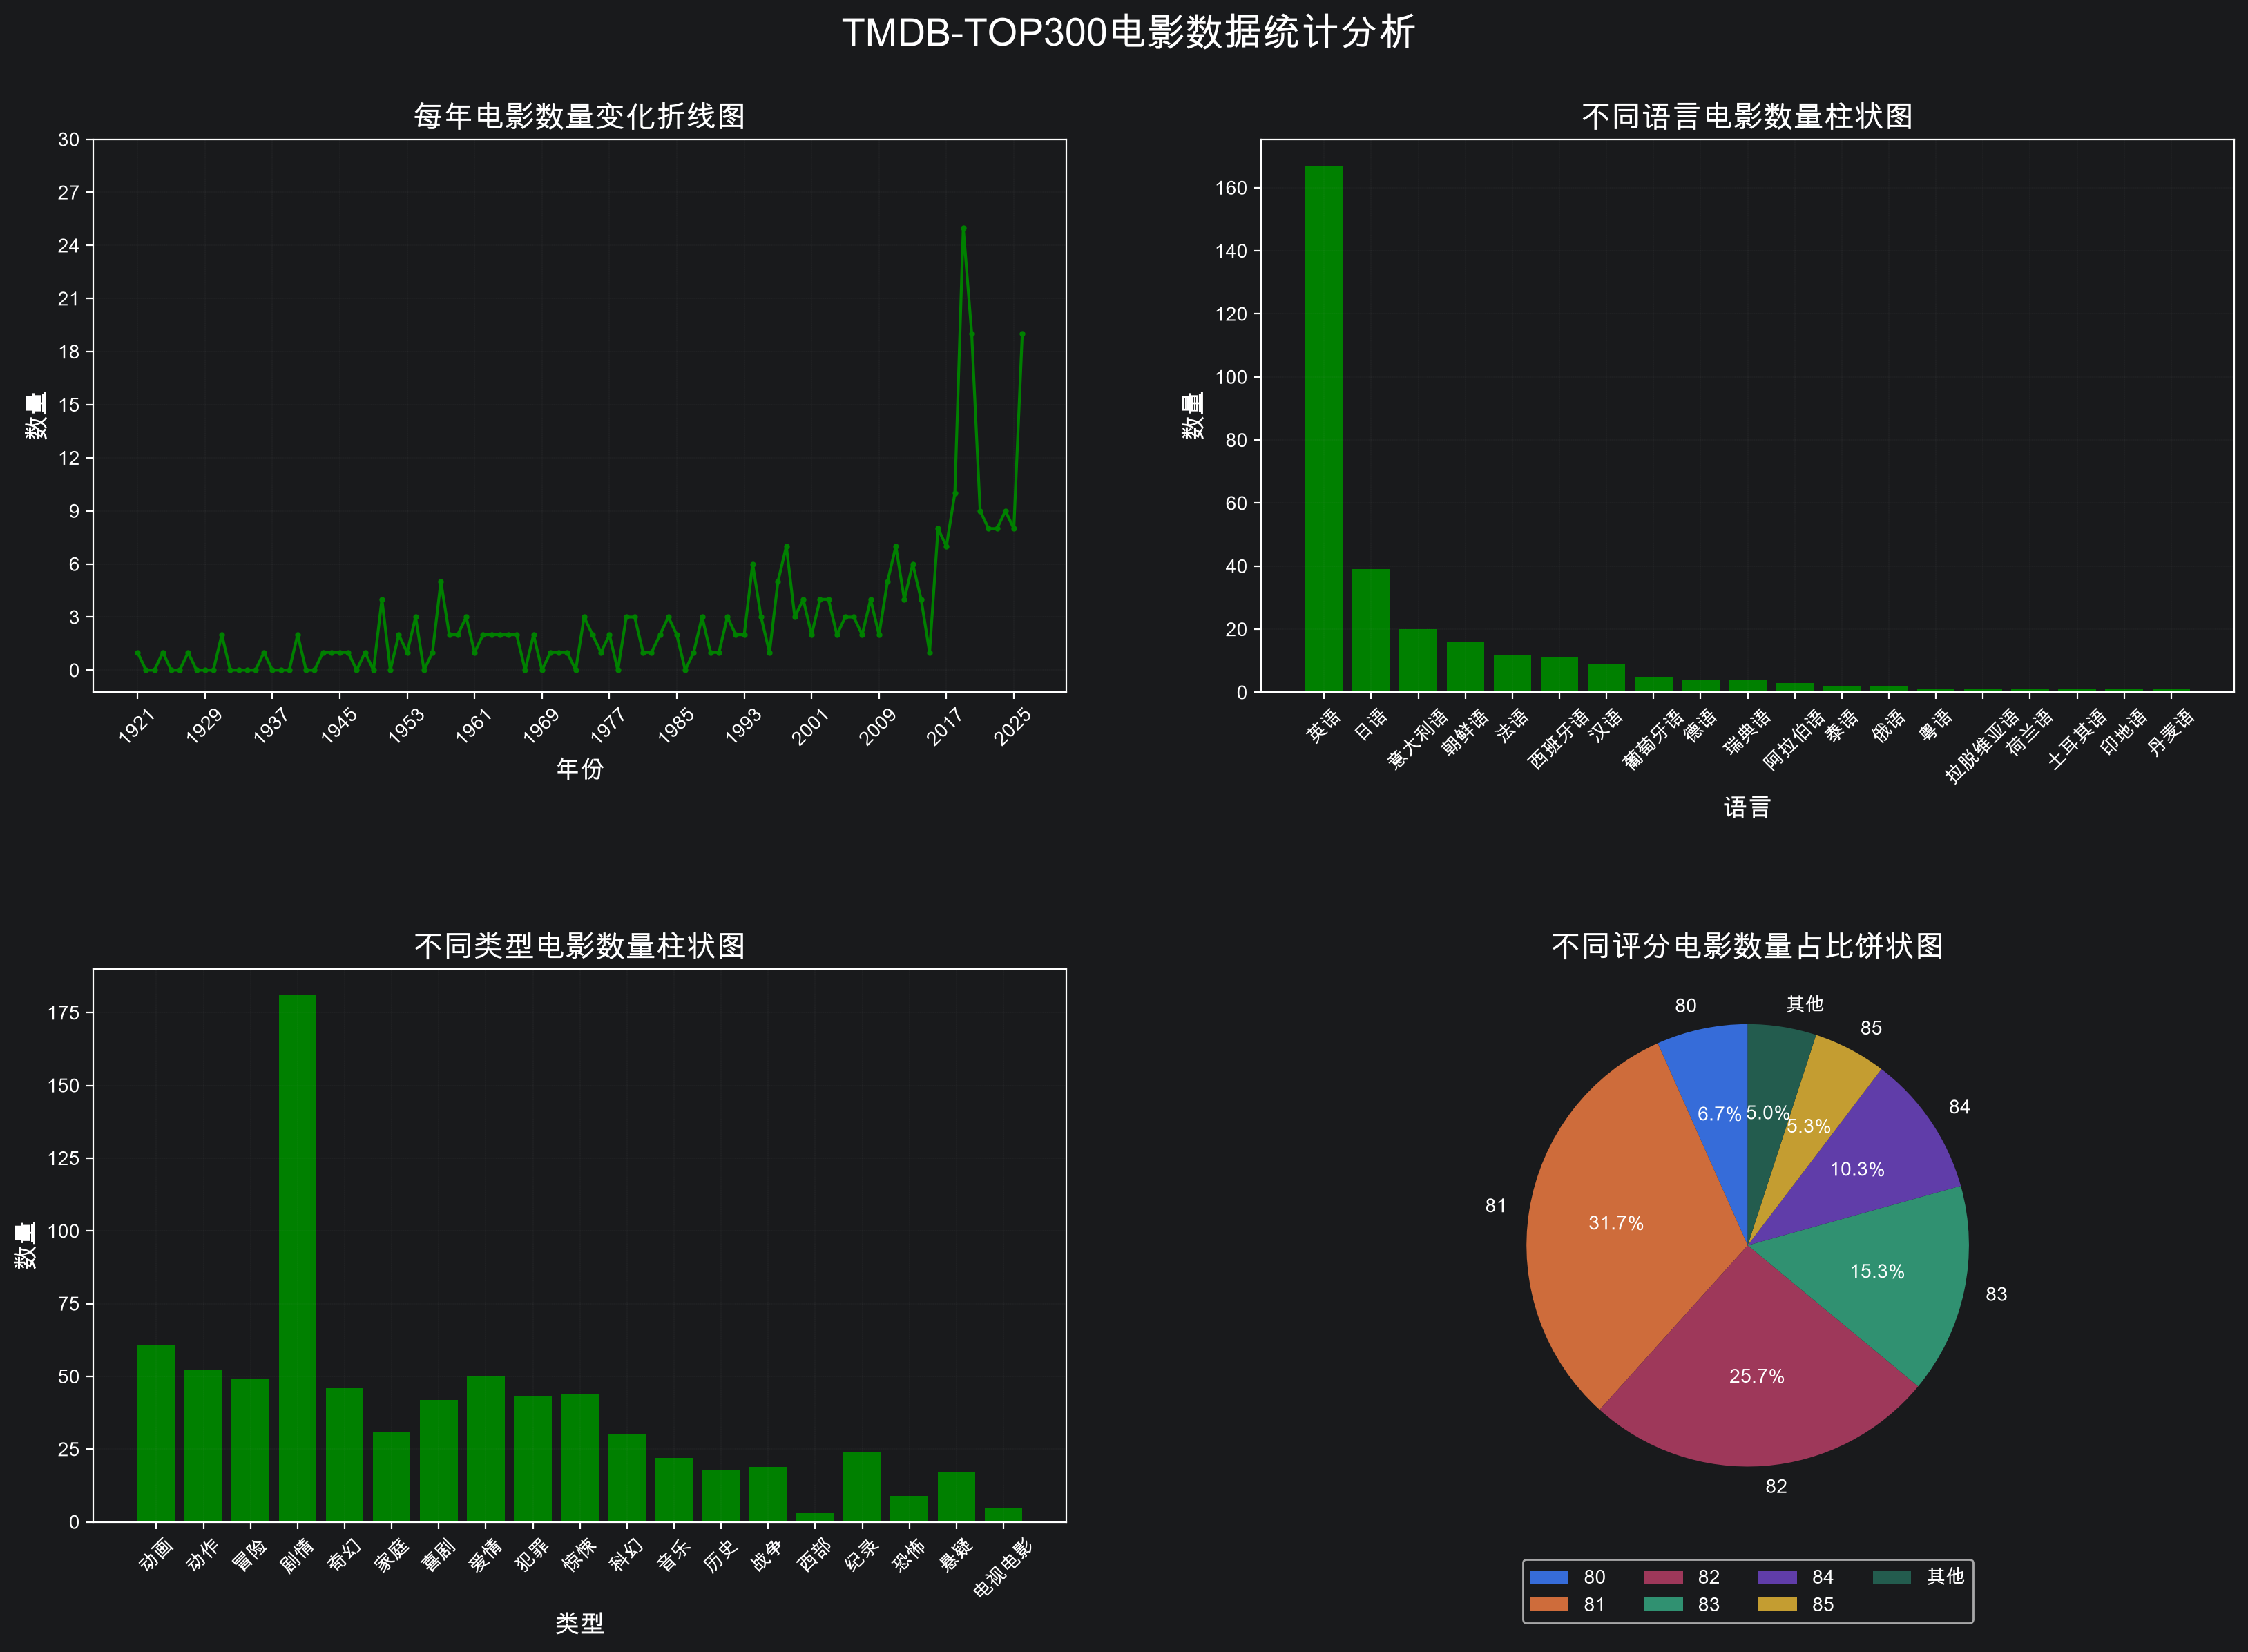

In [4]:
import pandas as pd
from pandas import Series
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

# 设置 Jupyter 内联输出为 Retina 高清格式
%config InlineBackend.figure_format = 'retina'

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
# 正常显示负号
plt.rcParams["axes.unicode_minus"] = False

# 创建子图
figure, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 13), dpi=100)  # nrows: 行 , ncols: 列
figure.suptitle('TMDB-TOP300电影数据统计分析', fontsize=20, x=0.5, y=0.95)  # 添加画布标题
figure.subplots_adjust(hspace=0.5, wspace=0.2)  # 调整子图间距，hspace: 控制垂直间距，wspace: 控制水平间距

# 获取子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
data = pd.read_csv('./data/movies.csv', usecols=['电影名称', '年份', '上映时间', '类型', '时长', '评分', '语言'],
                   dtype={'年份': 'Int64'})  # int64 : 整型数字（不支持空值）Int64 : 整型数字（支持空值）float64 : 浮点型数字（支持空值）

# 1. 需求一：统计TOP300的电影中，每一年上映的电影数量的变化 - 折线图
# 1.1 缺失值、异常值处理
# data.isnull().sum() # 统计缺失值数量
# data[data['年份'] < 0].count()  # 统计异常值数量
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 1.2 统计分组
year_count = data.groupby('年份')['年份'].count()

# 1.3 组装数据
# X轴
year_min = year_count.index.min()
year_max = year_count.index.max()
x = [i for i in range(year_min, year_max + 1)]
# Y轴
y = [year_count.get(i, 0) for i in x]

# 1.4 绘制折线图
axes1.plot(x, y, marker='o', markersize=2, color='green')
axes1.set_title('每年电影数量变化折线图', fontsize=16)
axes1.set_xlabel('年份', fontsize=13)
axes1.set_ylabel('数量', fontsize=13)
axes1.set_xticks(x[::8])
axes1.set_yticks([i for i in range(0, 31, 3)])
axes1.grid(linestyle='--', linewidth=0.1, alpha=0.3)
axes1.tick_params(axis='x', rotation=45)  # 旋转X轴标签

# 2. 需求二：统计对比不同语言的电影数量 - 柱状图
# 2.1 获取不同语言对应的电影数量
lang_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)  # 降序

lang_x = lang_count.index.tolist()  # X轴
lang_y = lang_count.values.tolist()  # Y轴

# 2.2 绘制柱状图
axes2.bar(lang_x, lang_y, color='green', width=0.8)  # 柱状图
axes2.set_title('不同语言电影数量柱状图', fontsize=16)  # 设置子图标题
axes2.set_xlabel('语言', fontsize=13)  # 设置X轴标签
axes2.set_ylabel('数量', fontsize=13)  # 设置Y轴标签
axes2.grid(linestyle='--', linewidth=0.1, alpha=0.3)  # 设置网格线
axes2.tick_params(axis='x', rotation=45)  # 旋转X轴标签

# 3. 需求三：统计对比不同类型电影数量 - 柱状图
# 3.1 获取不同类型对应的电影数量
type_count = {}  # {'动作' : 8, '冒险' : 6}
for types in data['类型'].str.split('、'):
    for t in types:
        if t in type_count:
            type_count[t] += 1
        else:
            type_count[t] = 1

x_types = list(type_count.keys())
y_values = list(type_count.values())

# 3.2 绘制柱状图
axes3.bar(x_types, y_values, color='green', width=0.8)  # 柱状图
axes3.set_title('不同类型电影数量柱状图', fontsize=16)  # 设置子图标题
axes3.set_xlabel('类型', fontsize=13)  # 设置X轴标签
axes3.set_ylabel('数量', fontsize=13)  # 设置Y轴标签
axes3.grid(linestyle='--', linewidth=0.1, alpha=0.3)  # 设置网格线
axes3.tick_params(axis='x', rotation=45)  # 旋转X轴标签

# 4. 需求四：统计对比各个评分的电影数量占比 - 饼状图
# 4.1 获取不同评分对应的电影数量
score_count = data.groupby('评分')['评分'].count()

# 4.2 合并小数据（比例＜3%）--＞其他
total = score_count.sum()
large_scores: Series = score_count.loc[score_count >= total * 0.03]  # 大数据 比例 >= 3%
small_scores: Series = score_count.loc[score_count < total * 0.03]  # 小数据 比例 < 3%

if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()
scores_values = large_scores.values.tolist()

# 4.3 绘制饼状图
axes4.pie(scores_values, labels=scores, autopct='%1.1f%%', startangle=90)
axes4.set_title('不同评分电影数量占比饼状图', fontsize=16)
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))

# 5. 保存图片
plt.savefig('./data/TMDB-TOP300.png', dpi=300)

plt.show()
